# 批量将含ToT名称的Timepix文本矩阵渲染为放大PNG图片

- 输入：任意目录下包含“ToT”关键字且以 .txt 结尾的 256×256 空格分隔矩阵文件（元素为像素能量值）。
- 渲染规则：0 像素为白色；>0 像素为黄色系，数值越大颜色越深（更“浓”）。
- 输出：PNG 图片，保持相对层级到输出目录，支持等比例放大并保持像素格感。
- 适用：Timepix 探测器 256×256 数据；若文件尺寸不符会跳过并记录。

使用步骤：
1) 在“参数设置”单元中，设置输入目录 in_dir（默认示例目录）与输出目录 out_dir、放大倍数 scale 等；
2) 运行“构建ToT文件列表”检查扫描结果；
3) 运行“预览首个文件渲染效果”快速检查着色是否符合预期；
4) 运行“批量渲染并保存PNG”完成转换；
5) 日志会保存在输出目录下的 render_log.json。

In [78]:
# 导入依赖
from __future__ import annotations
import os
import json
from pathlib import Path
from typing import Tuple, Dict, Any

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib import cm
from PIL import Image

try:
    from tqdm import tqdm
except Exception:
    # 简易后备方案：tqdm 不可用时提供兼容接口
    def tqdm(it, **kwargs):
        return it

# 在 Notebook 中展示图像更清晰
%matplotlib inline

In [79]:
# 参数设置（输入/输出/放大/归一化）
# 可按需修改这些参数后再运行后续单元

# 输入根目录（递归搜集 *ToT*.txt）
# 示例：使用仓库中的 AlphaAnalysis -> data -> Alpha -> 2 -> ToT 目录
in_dir = r"d:\Project\Timepix\AlphaAnalysis\data\Alpha\3\ToT"
    
# 输出根目录（将保持相对层级结构）
out_dir = r"D:\Project\Timepix\ProcessData\Images\3"

# 文件名包含关键词（用于筛选）
kw = "ToT"

# 渲染插值方式（'nearest' 可保留像素格感）
interpolation = 'nearest'

# 放大倍数（等比例，如 2~6）
scale = 4

# 是否采用百分位归一化（对非零像素），更稳健地抑制极端峰值
use_percentile = True
pmax = 99.5  # 上界百分位

# 是否在每张图内部分别归一化（True）或全局归一化（False）
per_image_normalize = True

# 针对 100x100 数据：是否仅保留中心 32×32 区域进行渲染
crop_for_100 = True
crop_size = 32  # 保留的中心窗口大小

# 随机预览的最大数量（仅用于预览单元可选）
preview_max = 1

# 输出目录创建
Path(out_dir).mkdir(parents=True, exist_ok=True)
print(f"输入根目录: {in_dir}\n输出根目录: {out_dir}\n100x100 裁剪: {'开启' if crop_for_100 else '关闭'}, 窗口={crop_size}×{crop_size}")

输入根目录: d:\Project\Timepix\AlphaAnalysis\data\Alpha\3\ToT
输出根目录: D:\Project\Timepix\ProcessData\Images\3
100x100 裁剪: 开启, 窗口=32×32


In [80]:
# 构建ToT文件列表
in_path = Path(in_dir)
if not in_path.exists():
    raise FileNotFoundError(f"输入目录不存在: {in_path}")

candidates = sorted([p for p in in_path.rglob(f"*{kw}*.txt") if p.is_file()])
print(f"共找到 {len(candidates)} 个候选文件（包含 '{kw}' 且以 .txt 结尾）。")
if len(candidates) == 0:
    print("未找到待处理文件，请检查 in_dir 或 kw 设置。")

# 预览前几个路径
for i, p in enumerate(candidates[:min(5, len(candidates))]):
    print(f"[{i+1}] {p}")

共找到 3526 个候选文件（包含 'ToT' 且以 .txt 结尾）。
[1] d:\Project\Timepix\AlphaAnalysis\data\Alpha\3\ToT\1_r0000_track001_ToT.txt
[2] d:\Project\Timepix\AlphaAnalysis\data\Alpha\3\ToT\1_r0000_track003_ToT.txt
[3] d:\Project\Timepix\AlphaAnalysis\data\Alpha\3\ToT\1_r0004_track001_ToT.txt
[4] d:\Project\Timepix\AlphaAnalysis\data\Alpha\3\ToT\1_r0008_track001_ToT.txt
[5] d:\Project\Timepix\AlphaAnalysis\data\Alpha\3\ToT\1_r0008_track002_ToT.txt


In [81]:
# 定义颜色映射与归一化（0为白，>0为黄色加深）

def build_norm_for_data(data: np.ndarray, use_percentile: bool = True, pmax: float = 99.5) -> colors.Normalize:
    """
    针对 data（二维）构建归一化器，仅对 >0 的像素做归一化：
    - vmin 为非零像素的最小值
    - vmax 为非零像素的最大值或百分位上界（pmax）
    - 0 值将通过掩码单独映射为白色
    """
    nz = data[data > 0]
    if nz.size == 0:
        # 全为 0 的情况，给一个兜底的归一化，避免除零
        return colors.Normalize(vmin=0, vmax=1)

    vmin = float(np.min(nz))
    if use_percentile:
        vmax = float(np.percentile(nz, pmax))
        vmax = max(vmax, vmin)
    else:
        vmax = float(np.max(nz))

    if vmax == vmin:
        vmax = vmin + 1.0

    return colors.Normalize(vmin=vmin, vmax=vmax, clip=True)


def get_yellow_cmap() -> colors.Colormap:
    """获取黄色系渐变，并将无效/掩码值设为白色。"""
    cmap = cm.get_cmap('YlOrBr').copy()
    cmap.set_bad('white')  # 掩码像素（如 0）用白色
    cmap.set_under('white')
    return cmap


def map_to_rgba(data: np.ndarray,
                norm: colors.Normalize,
                cmap: colors.Colormap) -> np.ndarray:
    """
    将 data（二维）映射为 RGBA（H×W×4，0~255）。0 值映射为白色。
    """
    # 掩码 0 值，以便被 cmap 的 bad 颜色（白色）接管
    masked = np.ma.masked_equal(data, 0)
    rgba_float = cmap(norm(masked))  # 返回 0~1 的 RGBA
    rgba = (rgba_float * 255).astype(np.uint8)
    return rgba

In [82]:
# 加载与校验单个文件矩阵（放宽为任意二维矩阵，若非256×256仅告警）

def load_tot_txt(path: Path) -> np.ndarray:
    """
    读取 ToT 文本，返回 int32 的二维矩阵；若不是二维抛异常；
    若形状不是 256x256，仅打印警告但继续处理（数据将按原尺寸或裁剪后渲染）。
    """
    try:
        arr = np.loadtxt(path, dtype=np.int32)
    except Exception as e:
        raise ValueError(f"读取失败: {path} -> {e}")

    if arr.ndim != 2:
        raise ValueError(f"数据并非二维矩阵: {path} -> shape={arr.shape}")

    if arr.shape != (256, 256):
        print(f"[WARN] 非 256x256 数据: {path.name} -> shape={arr.shape}，将按原尺寸/裁剪后渲染。")
    return arr


def center_crop_for_shape(data: np.ndarray, target_shape=(100, 100), crop_size: int = 32) -> np.ndarray:
    """
    若 data 形状为 target_shape（默认 100×100），则提取中心 crop_size×crop_size 的窗口；
    否则原样返回。
    """
    h, w = data.shape
    if (h, w) == tuple(target_shape):
        ch = cw = int(crop_size)
        if ch > h or cw > w:
            raise ValueError(f"裁剪窗口 {ch}x{cw} 超过数据尺寸 {h}x{w}")
        top = (h - ch) // 2
        left = (w - cw) // 2
        return data[top:top+ch, left:left+cw]
    return data


def preprocess_data(data: np.ndarray, enable_crop_for_100: bool = True, crop_size: int = 32) -> np.ndarray:
    """
    数据预处理：当尺寸为 100×100 且启用时，仅保留中心 crop_size×crop_size 区域。
    其他尺寸不变。
    """
    if enable_crop_for_100:
        return center_crop_for_shape(data, target_shape=(100, 100), crop_size=crop_size)
    return data

预览文件: d:\Project\Timepix\AlphaAnalysis\data\Alpha\3\ToT\1_r0000_track001_ToT.txt
[WARN] 非 256x256 数据: 1_r0000_track001_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。


C:\Users\27964\AppData\Local\Temp\ipykernel_21692\895824095.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlOrBr').copy()


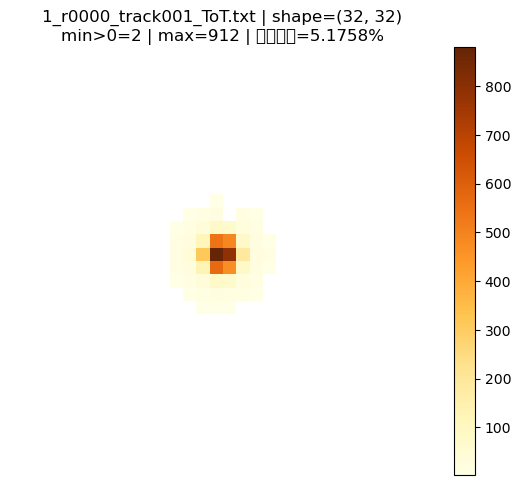

In [83]:
# 预览首个文件渲染效果（可选）

if len(candidates) > 0:
    sample_path = candidates[0]
    print(f"预览文件: {sample_path}")

    data_raw = load_tot_txt(sample_path)
    data = preprocess_data(data_raw, enable_crop_for_100=crop_for_100, crop_size=crop_size)

    # 选择归一化范围：按每张 or 全局（这里按预处理后数据）
    if per_image_normalize:
        norm = build_norm_for_data(data, use_percentile=use_percentile, pmax=pmax)
    else:
        norm = build_norm_for_data(data, use_percentile=use_percentile, pmax=pmax)

    cmap = get_yellow_cmap()

    masked = np.ma.masked_equal(data, 0)
    plt.figure(figsize=(6, 6))
    im = plt.imshow(masked, cmap=cmap, norm=norm, interpolation=interpolation)
    nzmin = data[data>0].min() if (data>0).any() else 'NA'
    plt.title(f"{sample_path.name} | shape={data.shape}\nmin>0={nzmin} | max={data.max()} | 非零占比={100.0*((data>0).sum()/data.size):.4f}%")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.axis('off')
    plt.show()
else:
    print("无可预览文件。")

In [84]:
# 批量渲染并保存PNG（保持相对目录）

def render_array_and_save(data: np.ndarray,
                          path_in: Path,
                          base_in: Path,
                          base_out: Path,
                          norm: colors.Normalize,
                          cmap: colors.Colormap,
                          scale: int = 4,
                          interpolation: str = 'nearest') -> Path:
    """
    将给定二维数组 data 渲染为 RGBA 并保存为 PNG，保持与输入文件相对层级。
    """
    rgba = map_to_rgba(data, norm=norm, cmap=cmap)
    img = Image.fromarray(rgba, mode='RGBA')
    if scale and scale > 1:
        img = img.resize((img.width * scale, img.height * scale), Image.NEAREST if interpolation == 'nearest' else Image.BILINEAR)

    rel = path_in.relative_to(base_in)
    out_png = base_out.joinpath(rel).with_suffix('.png')
    out_png.parent.mkdir(parents=True, exist_ok=True)
    img.save(out_png)
    return out_png


def render_and_save(path_in: Path,
                    base_in: Path,
                    base_out: Path,
                    norm: colors.Normalize,
                    cmap: colors.Colormap,
                    scale: int = 4,
                    interpolation: str = 'nearest',
                    enable_crop_for_100: bool = True,
                    crop_size: int = 32) -> Path:
    """
    读取 path_in -> 预处理（如 100×100 居中裁剪）-> 渲染为 RGBA -> 放大 -> 保存 PNG。
    返回输出路径。
    """
    data_raw = load_tot_txt(path_in)
    data = preprocess_data(data_raw, enable_crop_for_100=enable_crop_for_100, crop_size=crop_size)
    return render_array_and_save(data, path_in, base_in, base_out, norm, cmap, scale=scale, interpolation=interpolation)


# 批量处理
success, failed = 0, 0
errors: Dict[str, str] = {}

# 若选择全局归一化，需要先确定全局 norm（这里按首个文件的预处理后数据估计）
if not per_image_normalize and len(candidates) > 0:
    try:
        sample = preprocess_data(load_tot_txt(candidates[0]), enable_crop_for_100=crop_for_100, crop_size=crop_size)
        global_norm = build_norm_for_data(sample, use_percentile=use_percentile, pmax=pmax)
    except Exception:
        global_norm = colors.Normalize(vmin=1, vmax=2)
else:
    global_norm = None

cmap = get_yellow_cmap()

for p in tqdm(candidates, desc="渲染中"):
    try:
        if per_image_normalize:
            data_raw = load_tot_txt(p)
            data = preprocess_data(data_raw, enable_crop_for_100=crop_for_100, crop_size=crop_size)
            norm = build_norm_for_data(data, use_percentile=use_percentile, pmax=pmax)
            _ = render_array_and_save(data, p, in_path, Path(out_dir), norm, cmap, scale=scale, interpolation=interpolation)
        else:
            norm = global_norm if global_norm is not None else colors.Normalize(vmin=1, vmax=2)
            _ = render_and_save(p, in_path, Path(out_dir), norm, cmap, scale=scale, interpolation=interpolation,
                                enable_crop_for_100=crop_for_100, crop_size=crop_size)
        success += 1
    except Exception as e:
        failed += 1
        errors[str(p)] = str(e)

print(f"完成：成功 {success}，失败 {failed}。输出目录：{out_dir}")

C:\Users\27964\AppData\Local\Temp\ipykernel_21692\895824095.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlOrBr').copy()
渲染中:   0%|          | 0/3526 [00:00<?, ?it/s]

[WARN] 非 256x256 数据: 1_r0000_track001_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 1_r0000_track003_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 1_r0004_track001_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 1_r0008_track001_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 1_r0008_track002_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 1_r0009_track001_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 1_r0010_track001_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 1_r0011_track002_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 1_r0011_track003_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 1_r0011_track004_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 1_r0012_track002_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 1_r0014_track001_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 1_r0015_track002_ToT.txt -> sha

C:\Users\27964\AppData\Local\Temp\ipykernel_21692\1998245922.py:15: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(rgba, mode='RGBA')
渲染中:   1%|          | 42/3526 [00:00<00:08, 411.12it/s]

[WARN] 非 256x256 数据: 1_r0050_track002_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 1_r0052_track002_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 1_r0052_track004_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 1_r0052_track005_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 1_r0053_track003_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 1_r0053_track005_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 1_r0054_track002_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 1_r0056_track004_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 1_r0058_track001_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 1_r0058_track002_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 1_r0059_track001_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 1_r0062_track001_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 1_r0062_track002_ToT.txt -> sha

渲染中:   2%|▏         | 84/3526 [00:00<00:08, 386.08it/s]

...

[WARN] 非 256x256 数据: 2_r2229_track004_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2229_track005_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2231_track002_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2234_track002_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2236_track001_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2238_track001_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2238_track004_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2238_track005_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2239_track002_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2241_track001_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2245_track004_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2246_track002_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2248_track002_ToT.txt -> sha

渲染中:  99%|█████████▉| 3493/3526 [00:11<00:00, 339.28it/s]

[WARN] 非 256x256 数据: 2_r2332_track002_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2334_track002_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2335_track003_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2335_track004_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2336_track001_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2336_track002_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2338_track004_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2343_track001_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2344_track001_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2345_track001_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2347_track002_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2347_track003_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2352_track001_ToT.txt -> sha

渲染中: 100%|██████████| 3526/3526 [00:11<00:00, 313.28it/s]

[WARN] 非 256x256 数据: 2_r2428_track002_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2429_track001_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2430_track002_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2431_track002_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2432_track002_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2432_track004_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2433_track002_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2433_track003_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2433_track004_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2437_track004_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2438_track004_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2438_track005_ToT.txt -> shape=(100, 100)，将按原尺寸/裁剪后渲染。
[WARN] 非 256x256 数据: 2_r2438_track008_ToT.txt -> sha

In [85]:
# 处理异常与日志

summary = {
    "input_dir": str(in_dir),
    "output_dir": str(out_dir),
    "keyword": kw,
    "scale": scale,
    "use_percentile": use_percentile,
    "pmax": pmax,
    "per_image_normalize": per_image_normalize,
    "files_total": len(candidates),
    "success": success,
    "failed": failed,
    "errors": errors,
}

log_path = Path(out_dir) / "render_log.json"
with open(log_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(f"日志已写入：{log_path}")
if failed:
    print("失败明细（最多显示5条）：")
    for i, (k, v) in enumerate(errors.items()):
        print(f"[{i+1}] {k} -> {v}")
        if i >= 4:
            break

日志已写入：D:\Project\Timepix\ProcessData\Images\3\render_log.json


In [86]:
# 简单单元测试（映射、形状与裁剪）

def _unit_test_color_mapping():
    """测试 0 -> 白色，正值随大小颜色加深（亮度下降）。"""
    small = np.array([
        [0, 0, 0, 0],
        [0, 1, 2, 0],
        [0, 3, 5, 0],
        [0, 0, 0, 0],
    ], dtype=np.int32)

    norm = build_norm_for_data(small, use_percentile=False)
    cmap = get_yellow_cmap()
    rgba = map_to_rgba(small, norm, cmap)

    white = rgba[0, 0, :3]
    assert np.allclose(white, np.array([255, 255, 255])), f"0 未映射为白色: {white}"

    # 取两个不同的正值像素，较大值应更“深”（亮度更低）
    p_low = rgba[1, 1, :3].astype(np.int32)
    p_high = rgba[2, 2, :3].astype(np.int32)
    # 简单比较灰度（非严格，仅确保趋势）
    gray_low = int(0.299 * p_low[0] + 0.587 * p_low[1] + 0.114 * p_low[2])
    gray_high = int(0.299 * p_high[0] + 0.587 * p_high[1] + 0.114 * p_high[2])
    assert gray_high < gray_low, f"高值像素未更深: gray_high={gray_high}, gray_low={gray_low}"

    print("颜色映射测试通过。")


def _unit_test_shape_and_crop():
    """测试 100×100 居中裁剪为 32×32。"""
    arr = np.zeros((100, 100), dtype=np.int32)
    # 在中心区域放置一个明显的非零点（裁剪后应保留）
    arr[50, 50] = 10
    cropped = center_crop_for_shape(arr, target_shape=(100, 100), crop_size=32)
    assert cropped.shape == (32, 32), f"裁剪结果尺寸错误: {cropped.shape}"
    # 裁剪后的坐标中心应包含非零点（相对 32×32 的中心附近）
    assert cropped[16, 16] == 10, "中心非零点未被保留"
    print("形状与裁剪测试通过。")


# 运行测试
a = _unit_test_color_mapping()
b = _unit_test_shape_and_crop()

颜色映射测试通过。
形状与裁剪测试通过。


C:\Users\27964\AppData\Local\Temp\ipykernel_21692\895824095.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlOrBr').copy()
